# Triton-based FlashAttention Implementation & Analysis
**Author** : 이나연 (Sookmyung Women's University, Dept. of AI Engineering)   
   
본 프로젝트는 **<FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness>** 논문의 **Algorithm 1**을 OpenAI Triton 및 Python을 이용해 직접 구현하고,    
기존 방식(Naive Attention) 및 PyTorch Native API와의 성능 및 메모리 효율성을 비교 분석한 프로젝트입니다.



In [ ]:
#triton 설치
!pip install triton

In [ ]:
#GPU 확인
!nvidia-smi

Thu Mar 12 15:21:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import triton
import triton.language as tl

@triton.jit
def flash_attn_kernel(
      Q, K, V, L, M, Out, # 데이터가 담긴 HBM 주소들
      stride_qb, stride_qh, stride_qm, # (Q) 메모리에서 한 칸 이동할 때의 보폭
      stride_kb, stride_kh, stride_km, # (K)
      stride_vb, stride_vh, stride_vm, # (V)
      stride_ob, stride_oh, stride_om, # (O)
      n_heads, head_dim, # 모델의 설정값 (n_heads : 헤드 수 / head_dim : 헤드당 차원)
      N_CTX, #입력 토큰 개수
      HEAD_DIM: tl.constexpr,
      BLOCK_M: tl.constexpr, #B_r에 해당함
      BLOCK_N: tl.constexpr #B_c에 해당함
      # 컴파일 타임에 결정될 블록 크기
  ):
  #tl.constexpr : 성능을 위해 미리 설정하는 최적화용 상수.

  #로직 작성
  tl.static_assert(BLOCK_N <= HEAD_DIM) #에러 방지
  start_m = tl.program_id(0) #현재 담당하는 Query(Q)의 블록 인덱스
  off_hz = tl.program_id(1) #batch와 head를 하나로 묶은 인덱스
  off_z = off_hz // n_heads
  off_h = off_hz % n_heads

  # initialize offsets (block 안에서의 행/열 번호)
  offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
  offs_n = tl.arange(0, BLOCK_N)

  #Q 가로축을 위한 인덱스
  offs_k = tl.arange(0, HEAD_DIM)

  #Q 포인터 계산
  q_ptrs = Q + (off_z * stride_qb + off_h * stride_qh) + (offs_m[:, None] * stride_qm + offs_k[None, :] * 1)
  #q_ptrs를 따라 Q를 SRAM으로 가져오기
  q=tl.load(q_ptrs)

  #m과 l을 initialize하기
  m_i = tl.zeros([BLOCK_M], dtype=tl.float32) - float("inf")
  l_i = tl.zeros([BLOCK_M], dtype=tl.float32) + 0.0
  acc = tl.zeros([BLOCK_M, HEAD_DIM], dtype=tl.float32) #결과값을 담을 변수

  #나중에 Q랑 K를 연산할 때를 위한 scaling 상수 (값이 너무 커지는걸 방지)
  qk_scale = HEAD_DIM ** (-0.5) #head당 차원인 HEAD_DIM을 활용

  #for문 (바깥 루프)
  #algorithm1의 안쪽 루프는 파이썬 grid로 대체
  for start_n in range(0, N_CTX, BLOCK_N):
    #N_CTX만큼을 블록 단위로 끊어서 for문을 돎 (-> 즉 T_c)

    #(6번줄) 세로(N_CTX) 방향으로 start_n반큼 이동
    k_ptrs = K + (off_z * stride_kb + off_h * stride_kh) + ((start_n + tl.arange(0,BLOCK_N))[:, None]*stride_km + tl.arange(0, HEAD_DIM)[None, :]*1)
    v_ptrs = V + (off_z * stride_vb + off_h * stride_vh) + ((start_n + tl.arange(0,BLOCK_N))[:, None]*stride_vm + tl.arange(0, HEAD_DIM)[None, :]*1)

    k = tl.load(k_ptrs)
    v = tl.load(v_ptrs)

    #(9번줄) Sij = Qi * Kj^T 계산하기
    qk = tl.zeros([BLOCK_M, BLOCK_N], dtype=tl.float32)
    qk += tl.dot(q, tl.trans(k)) #trans 유의
    qk *= qk_scale

    #(10번줄) 현재 블록의 최댓값 m_ij와 지수 합 l_ij 구하기
    #for문이 돌고 있으므로, rowmax,sum이 수행되고 있음 (각 행에서 그 행에 속한 열들을 훑기)
    m_ij = tl.max(qk,1)
    p_ij = tl.exp(qk-m_ij[:,None])
    l_ij=tl.sum(p_ij, 1)

    #(11번줄) 논문에서는 m_i_new를 씀 유의
    m_i_old = m_i
    m_i = tl.maximum(m_i, m_ij) #두 값을 비교

    #보정 계수 계산
    alpha = tl.exp(m_i_old - m_i)
    beta = tl.exp(m_ij - m_i)

    #보정치 반영해서 l_i 업데이트
    l_i = alpha * l_i + beta * l_ij

    #결과값 acc 갱신
    p_v_ij = tl.dot(p_ij.to(tl.float16), v.to(tl.float16)) #P_ij * V_j
    acc = alpha[:, None] * acc + beta[:, None] * p_v_ij
    #보정치가 1차원 벡터기 때문에 128x1의 2차원 행렬로 만들어주는게 [:, None]

  #acc에 diag(l_i)^(-1)반영하기.(효율적으로 마지막에 적용)
  acc = acc / l_i[:, None]

  #최종 결과 HBM에 저장하기
  off_o = (off_z * stride_ob + off_h * stride_oh) + (offs_m[:, None] * stride_om + offs_k[None, :]*1)
  tl.store(Out + off_o, acc)

  #역전파를 위해 m_i와 l_i 저장하기
  tl.store(M + off_hz*N_CTX + offs_m, m_i)
  tl.store(L + off_hz*N_CTX + offs_m, l_i)



In [19]:
#파이썬 grid
import torch

def flash_attn(q,k,v):
  #기본 정보 추출
  batch, n_heads, seq_len, head_dim = q.shape

  out = torch.empty_like(q)
  #역전파를 위해 저장하는 통계치
  L = torch.empty((batch*n_heads, seq_len), device=q.device, dtype=torch.float32)
  M = torch.empty((batch*n_heads, seq_len), device=q.device, dtype=torch.float32)

  #하이퍼파라미터 설정
  BLOCK_M = 128
  BLOCK_N = 64

  #GRID 설정
  #grid[0] = Q 블록(조각) 개수
  #grid[1] = Batch * Heaad
  grid = (triton.cdiv(seq_len, BLOCK_M), batch * n_heads)

  #커널 호출
  flash_attn_kernel[grid](
      q, k, v, L, M, out, # 데이터가 담긴 HBM 주소들 (포인터)
      q.stride(0), q.stride(1), q.stride(2), # (Q) 메모리에서 한 칸 이동할 때의 보폭
      k.stride(0), k.stride(1), k.stride(2), # (K)
      v.stride(0), v.stride(1), v.stride(2), # (V)
      out.stride(0), out.stride(1), out.stride(2), # (O)
      n_heads, head_dim, # 모델의 설정값
      seq_len, #입력 토큰 개수
      HEAD_DIM=head_dim,
      BLOCK_M=BLOCK_M,
      BLOCK_N=BLOCK_N #헷갈림 조심. 매개변수 이름이랑 변수 값
  )

  return out

In [20]:
#test 진행
#dummy data
q = torch.randn((2,8,1024, 64), device='cuda', dtype=torch.float16)
k = torch.randn((2,8,1024, 64), device='cuda', dtype=torch.float16)
v = torch.randn((2,8,1024, 64), device='cuda', dtype=torch.float16)

my_out = flash_attn(q,k,v)

print("결과 텐서 크기 :", my_out.shape)
print("계산 성공")

결과 텐서 크기 : torch.Size([2, 8, 1024, 64])
계산 성공


In [21]:
#PyTorch API와 비교하기
import torch

#pytorch 공식 api
torch_out = torch.nn.functional.scaled_dot_product_attention(q,k,v)

#오차 허용치 체크
is_correct = torch.allclose(my_out, torch_out, atol=1e-2, rtol=1e-2)
max_diff = (my_out - torch_out).abs().max().item()

print(f"정답과 일치 여부: {is_correct}")
print(f"최대 오차: {max_diff:.6f}")

정답과 일치 여부: True
최대 오차: 0.000244


In [22]:
#성능 벤치마킹
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

#실행 시간
ms = triton.testing.do_bench(lambda: flash_attn(q,k,v))

#메모리 사용량 측정 (HBM)
#peak memory -> 가장 peak(최고점)였을 때의 메모리 사용량
peak_mem = torch.cuda.max_memory_allocated() / (1024**2)

#연산 효율(TFLOPS) 계산
batch, n_heads, seq_len, head_dim = q.shape
flops = 2 * batch*n_heads*(seq_len**2)*head_dim
tflops=(flops / (ms*1e-3)) / 1e12

print(f"실행 시간: {ms:.3f}ms")
print(f"연산 효율: {tflops:.2f}TFLOPS")
print(f"peak 메모리 : {peak_mem:.2f} MiB")

실행 시간: 34.099ms
연산 효율: 0.06TFLOPS
peak 메모리 : 281.00 MiB


N=16384: Naive Attention에서 OOM 발생


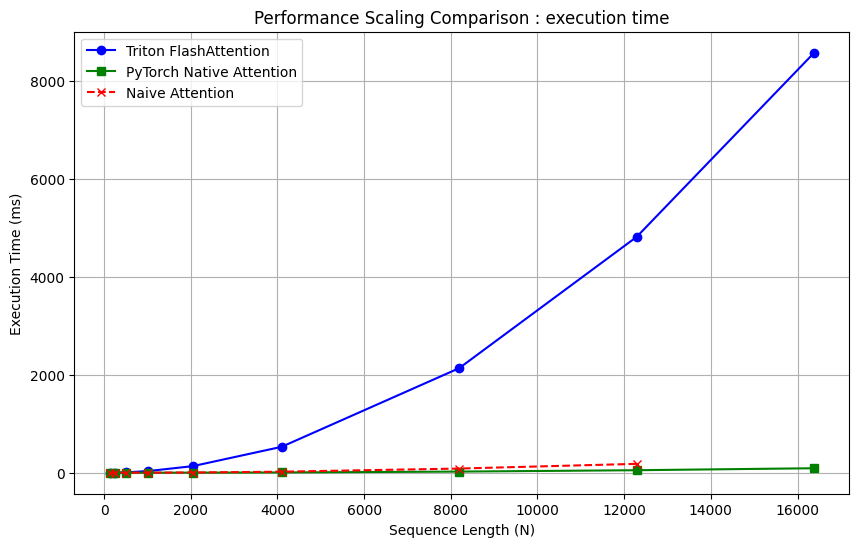

In [24]:
#Matplotlib으로 성능 시각화하기
import matplotlib.pyplot as plt

#일반적인 attention (O^n 방식)
def naive_attention(q,k,v):
  scale = q.shape[-1] ** -0.5

  #NxN 행렬 HBM에 통째로 생성하기
  attn = torch.matmul(q,k.transpose(-2, -1)) * scale
  attn = attn.softmax(dim=-1)
  return torch.matmul(attn, v)

def profile_scaling():
  #test할 sequence 길이 (N) 설정
  configs = [128, 256, 512, 1024, 2048, 4096, 8192, 12288, 16384]
  #결과 저장할 리스트
  triton_times = []
  torch_times = []
  naive_times = []

  for n in configs:
    q_test = torch.randn((2,8,n, 64), device='cuda', dtype=torch.float16)
    k_test = torch.randn((2,8,n, 64), device='cuda', dtype=torch.float16)
    v_test = torch.randn((2,8,n, 64), device='cuda', dtype=torch.float16)

    #triton 커널
    triton_times.append(triton.testing.do_bench(lambda: flash_attn(q_test, k_test, v_test)))
    #PyTorch 최적화 버전
    torch_times.append(triton.testing.do_bench(lambda: torch.nn.functional.scaled_dot_product_attention(q_test, k_test, v_test)))

    try:
      #일반적인 attention 연산
      naive_times.append(triton.testing.do_bench(lambda: naive_attention(q_test, k_test,v_test)))
    except torch.cuda.OutOfMemoryError:
      #OOM 방지
      naive_times.append(float('nan'))
      print(f"N={n}: Naive Attention에서 OOM 발생")

  plt.figure(figsize=(10,6))
  plt.plot(configs, triton_times, label="Triton FlashAttention", marker="o", color="blue")
  plt.plot(configs, torch_times, label="PyTorch Native Attention", marker="s", color="green")
  plt.plot(configs, naive_times, label="Naive Attention", marker="x", linestyle="--", color="red")

  plt.xlabel("Sequence Length (N)")
  plt.ylabel("Execution Time (ms)")
  plt.title("Performance Scaling Comparison : execution time")
  plt.legend()
  plt.grid(True)
  plt.show()

profile_scaling()

N=16384: Naive Attention에서 OOM 발생
         N |     Triton (MB) |     Native (MB) |      Naive (MB)
------------------------------------------------------------
       128 |          371.89 |          371.88 |          372.62
       256 |          372.91 |          372.88 |          376.38
       512 |          374.94 |          374.88 |          389.88
      1024 |          379.00 |          378.88 |          440.88
      2048 |          387.12 |          386.88 |          638.88
      4096 |          403.38 |          402.88 |         1418.88
      8192 |          435.88 |          434.88 |         4514.88
     12288 |          468.38 |          466.88 |         9658.88
     16384 |          500.88 |          498.88 |             nan


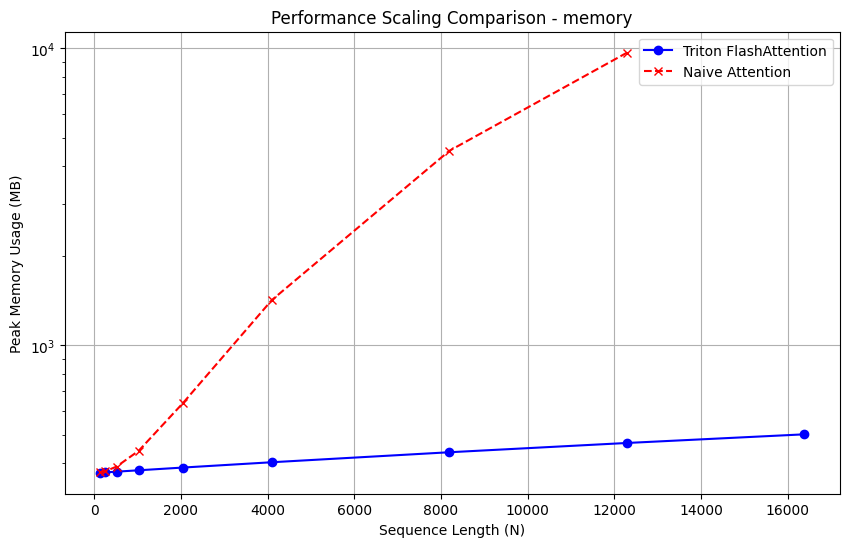

In [25]:
def get_peak_memory(func):
  #메모리 기록 정리
  torch.cuda.empty_cache()
  torch.cuda.reset_peak_memory_stats()

  func()

  #실행 되는 동안의 peak(최고점) 메모리 반환
  peak_mem=torch.cuda.max_memory_allocated() / (1024 ** 2)
  return peak_mem

def profile_scaling():
  configs = [128, 256, 512, 1024, 2048, 4096, 8192, 12288, 16384]
  triton_memory = []
  torch_memory  = []
  naive_memory  = []

  for n in configs:
    q_test = torch.randn((2,8,n, 64), device='cuda', dtype=torch.float16)
    k_test = torch.randn((2,8,n, 64), device='cuda', dtype=torch.float16)
    v_test = torch.randn((2,8,n, 64), device='cuda', dtype=torch.float16)

    #triton 커널
    triton_memory.append(get_peak_memory(lambda: flash_attn(q_test, k_test, v_test)))
    #PyTorch 최적화 버전
    torch_memory.append(get_peak_memory(lambda: torch.nn.functional.scaled_dot_product_attention(q_test, k_test, v_test)))

    try:
      #일반적인 attention 연산
      naive_memory.append(get_peak_memory(lambda: naive_attention(q_test, k_test,v_test)))
    except torch.cuda.OutOfMemoryError:
      #OOM 방지 코드
      naive_memory.append(float('nan'))
      print(f"N={n}: Naive Attention에서 OOM 발생")

  plt.figure(figsize=(10,6))
  plt.plot(configs, triton_memory, label="Triton FlashAttention", marker="o", color="blue")
  #plt.plot(configs, torch_memory, label="PyTorch Native Attention", marker="s", color="green")
  plt.plot(configs, naive_memory, label="Naive Attention", marker="x", linestyle="--", color="red")
  print(f"{'N':>10} | {'Triton (MB)':>15} | {'Native (MB)':>15} | {'Naive (MB)':>15}")

  print("-" * 60)
  for i, n in enumerate(configs):
      t_mem = triton_memory[i]
      p_mem = torch_memory[i]
      n_mem = naive_memory[i]
      print(f"{n:10d} | {t_mem:15.2f} | {p_mem:15.2f} | {n_mem:15.2f}")

  plt.xlabel("Sequence Length (N)")
  plt.ylabel("Peak Memory Usage (MB)")
  plt.yscale('log')
  plt.title("Performance Scaling Comparison - memory")
  plt.legend()
  plt.grid(True)
  plt.show()

profile_scaling()